In [1]:
import pandas as pd             # data package
import matplotlib.pyplot as plt # graphics 
import datetime as dt
import numpy as np
from scipy.stats.mstats import gmean

import matplotlib.ticker as mtick 

import requests, io             # internet and input tools  
import zipfile as zf            # zip file tools 
import os  

#import weightedcalcs as wc
#import numpy as np

import pyarrow as pa
import pyarrow.parquet as pq

In [2]:
country_list = pd.read_csv("C:\\heroku\\how-restrictive-us-trade\\data\\country-list.csv", header=None, names=["CTY_CODE"])

figfile = "C:\\github\\how-restrictive-us-trade\\figures\\"

texfile = "C:\\github\\how-restrictive-us-trade\\results.tex"

tabletex = "C:\\github\\how-restrictive-us-trade\\table.tex"

In [3]:
def make_tariff_country_date(dfcntry, date):
   
   bar = dfcntry[(dfcntry['time'] == date)].copy()

   bar["tariff"] = bar["CAL_DUT_MO"] / bar["CON_VAL_MO"]

   bar = bar[["I_COMMODITY", "CON_VAL_MO", "CAL_DUT_MO", "tariff", "CTY_NAME"]]

   return bar

In [4]:
def make_good_country_year(dfcntry, year):
    """
    Process country data for a specific year and calculate aggregate metrics.
    
    Parameters:
    -----------
    dfcntry : pandas.DataFrame
        DataFrame containing country trade data with columns:
        - time: datetime
        - I_COMMODITY: commodity code
        - CON_VAL_MO: consumption value
        - CAL_DUT_MO: calculated duty
        - CTY_NAME: country name
    year : str
        Year to filter data (e.g., "2024")
    
    Returns:
    --------
    pandas.DataFrame
        Aggregated data by commodity for the specified year
    """
    # Filter to specific year
    df_year = dfcntry[dfcntry['time']== year]
    
    # Group by commodity and aggregate
    grp = df_year.groupby("I_COMMODITY")
    
    result = grp.agg({
        "CON_VAL_MO": "sum",
        "CAL_DUT_MO": "sum",
        "CTY_NAME": "first"})
    
    
    return result

In [5]:
country_list.head()

,CTY_CODE
0,5700
1,2010
2,1220
3,5880
4,4280


In [6]:
def process_countries_for_date(country_list, target_date, weight_year="2024", selected_country=None):
    """
    Process multiple countries and create combined dataset with weights.
    
    Parameters:
    -----------
    country_list : pandas.DataFrame or list
        DataFrame with CTY_CODE column or list of country codes
    target_date : str
        Date to extract tariff data for (e.g., "2025-08")
    weight_year : str, optional
        Year to use for calculating weights (default: "2024")
    selected_country : str, optional
        Country name to filter results (e.g., "CANADA"). If None, returns all countries (default: None)
    
    Returns:
    --------
    pandas.DataFrame
        Combined dataframe with tariff data and weights for all countries (or selected country)
    """
    # Handle both DataFrame and list inputs
    if isinstance(country_list, pd.DataFrame):
        countries = country_list.CTY_CODE
    else:
        countries = country_list
    
    all_results = []
    tariff_results = []
    
    for country in countries:
        
        file = f"C:\\heroku\\median-tariff\\data\\imports-hs10\\{country}data-current.parquet"
        
        # Load country data
        dfcntry = pq.read_table(file).to_pandas()
        
        dfcntry["CAL_DUT_MO"] = dfcntry["CAL_DUT_MO"].astype(float)

        dfcntry["CON_VAL_MO"] = dfcntry["CON_VAL_MO"].astype(float)

        dfcntry.time = pd.to_datetime(dfcntry.time, format="%Y-%m")

        dfcntry["applied_tariff"] = dfcntry["CAL_DUT_MO"] / dfcntry["CON_VAL_MO"]
            
        # Calculate metrics for weight year
        results_df = make_good_country_year(dfcntry, weight_year)

        results_df.reset_index(inplace=True)
        
        # Get tariff data for target date
        tariff_df = make_tariff_country_date(dfcntry, target_date)

        tariff_df.reset_index(drop=True, inplace=True)
        
        # Add to lists
        all_results.append(results_df)

        tariff_results.append(tariff_df)
        
        #print(f"Processed {country}: {results_df['CTY_NAME'].iloc[0]}")
    
    # Combine all results into one dataframe
    combined_results = pd.concat(all_results)
    combined_results.reset_index(drop=True, inplace=True)
    
    combined_tariff_results = pd.concat(tariff_results)
    combined_tariff_results.reset_index(drop=True, inplace=True)
    
    # Calculate weights
    combined_results["weights"] = combined_results["CON_VAL_MO"] / combined_results["CON_VAL_MO"].sum()
    
    # Merge weights with tariff data
    bigdf = pd.merge(
        combined_results[["I_COMMODITY", "CTY_NAME", "weights"]], 
        combined_tariff_results, 
        how="left", 
        on=["I_COMMODITY", "CTY_NAME"]
    )
    
    # Filter to selected country if specified
    if selected_country is not None:
        bigdf = bigdf[bigdf["CTY_NAME"] == selected_country].copy()
        # Renormalize weights to sum to 1 for the selected country
        bigdf["weights"] = bigdf["weights"] / bigdf["weights"].sum()
    
    return bigdf

In [7]:
def create_tariff_metrics_by_date_country(country_list, date_list, weight_year="2024"):
    """
    Calculate tariff metrics for multiple dates and countries.
    
    Parameters:
    -----------
    country_list : pandas.DataFrame or list
        DataFrame with CTY_CODE column or list of country codes
    date_list : list
        List of date strings to process (e.g., ["2024-08", "2025-02", "2025-08"])
    weight_year : str, optional
        Year to use for calculating weights (default: "2024")
    
    Returns:
    --------
    pandas.DataFrame
        DataFrame with columns: date, CTY_NAME, sqrtariff, meanweighted, simplemean
    """
    results = []
    
    for date in date_list:
        print(f"Processing date: {date}")
        
        # Get data for this date (all countries)
        bigdf = process_countries_for_date(country_list, date, weight_year=weight_year)
        
        # Calculate metrics for ALL COUNTRIES combined
        sqrtariff_all = ((bigdf["tariff"]**2 * bigdf["weights"]).sum())**0.5
        meanweighted_all = (bigdf["tariff"] * bigdf["weights"]).sum()
        simplemean_all = bigdf['CAL_DUT_MO'].sum() / bigdf["CON_VAL_MO"].sum()
        
        # Store ALL COUNTRIES results
        results.append({
            'date': date,
            'CTY_NAME': 'ALL COUNTRIES',
            'sqrtariff': sqrtariff_all,
            'meanweighted': meanweighted_all,
            'simplemean': simplemean_all,
            "duty_total": bigdf['CAL_DUT_MO'].sum()
        })
        
        # Get unique countries in this dataset
        countries = bigdf['CTY_NAME'].unique()
        
        for country in countries:
            # Filter to this country
            country_df = bigdf[bigdf['CTY_NAME'] == country].copy()
            
            # Renormalize weights to sum to 1 for this country
            country_df["weights"] = country_df["weights"] / country_df["weights"].sum()
            
            # Calculate metrics
            sqrtariff = ((country_df["tariff"]**2 * country_df["weights"]).sum())**0.5
            meanweighted = (country_df["tariff"] * country_df["weights"]).sum()
            simplemean = country_df['CAL_DUT_MO'].sum() / country_df["CON_VAL_MO"].sum()
            
            # Store results
            results.append({
                'date': date,
                'CTY_NAME': country,
                'sqrtariff': sqrtariff,
                'meanweighted': meanweighted,
                'simplemean': simplemean,
                "duty_total": country_df['CAL_DUT_MO'].sum()
            })
    
    # Convert to DataFrame
    results_df = pd.DataFrame(results)
    
    return results_df

In [8]:
target_date = "2025-09"

bigdf = process_countries_for_date(country_list, target_date, weight_year="2024")

sqrtariff = ((bigdf["tariff"]**2 * bigdf["weights"]).sum())**0.5

print(f"Weighted TRI Tariff: {sqrtariff:.2%}")

meanweighted = (bigdf["tariff"] * bigdf["weights"]).sum()

print(" ")

print(f"Weighted Mean Tariff: {meanweighted:.2%}")

print(" ")

simplemean = bigdf['CAL_DUT_MO'].sum() / bigdf["CON_VAL_MO"].sum()

print(f"Simple Mean Tariff: {simplemean:.2%}")

# Format the date

formatted_date = pd.to_datetime(target_date, format="%Y-%m").strftime("%B %Y")

with open(texfile, 'w') as f:
    f.write(f'\\newcommand{{\\rmsValuetwofive}}{{{sqrtariff*100:.0f}}}\n')
    f.write(f'\\newcommand{{\\meanWeightedValuetwofive}}{{{meanweighted*100:.0f}}}\n')
    f.write(f'\\newcommand{{\\simpleMeanValuetwofive}}{{{simplemean*100:.0f}}}\n')
    f.write(f'\\newcommand{{\\currentdate}}{{{formatted_date}}}\n')
    f.write(f'\\newcommand{{\\diffmeanWeightedValuetwofive}}{{{(sqrtariff*100 - meanweighted*100):.0f}}}\n')
    f.write(f'\\newcommand{{\\diffsimpleMeanValuetwofive}}{{{(sqrtariff*100 - simplemean*100):.0f}}}\n')


Weighted TRI Tariff: 22.75%
 
Weighted Mean Tariff: 14.16%
 
Simple Mean Tariff: 10.60%


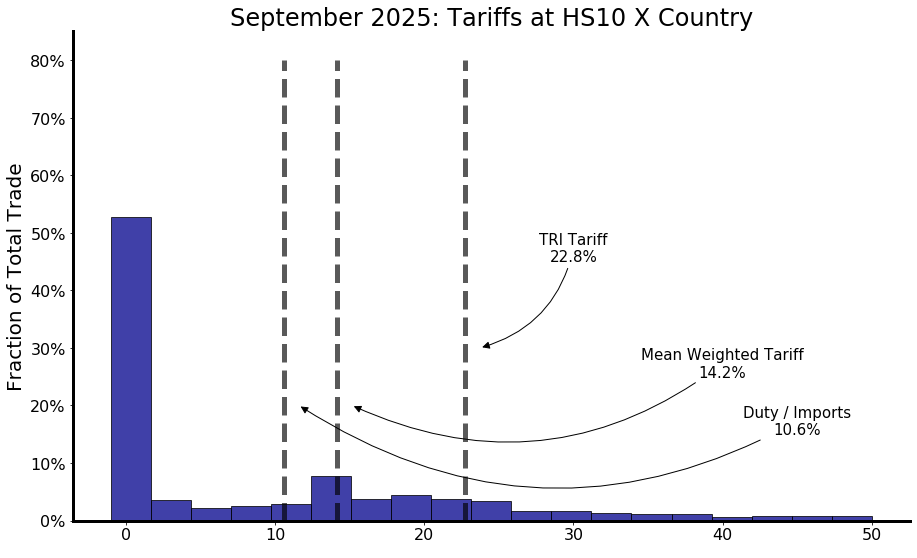

In [9]:
fig, ax = plt.subplots(figsize = (15,9))

# fig = plt.figure(figsize=(15, 9))
# bax_ax = bax.brokenaxes(ylims=((0, 0.20), (0.40, 0.50)), hspace=.05)

bin_edges = np.linspace(-1, 50, 20)  # 50 bins

# Digitize delta_tariff into bins
bin_indices = np.digitize(100*bigdf["tariff"], bin_edges) - 1

# Sum CON_VAL_MO in each bin
bin_sums = np.zeros(len(bin_edges) - 1)

for i in range(len(bin_sums)):

    bin_sums[i] = bigdf.loc[bin_indices == i, "CON_VAL_MO"].sum()

# Convert to fraction of total CON_VAL_MO
fractions = bin_sums / bigdf["CON_VAL_MO"].sum()

ax.bar(bin_edges[:-1], fractions, width=np.diff(bin_edges), 
       align='edge', color='darkblue', alpha=0.75, edgecolor='black')

# ax.set_ylim(top=0.95)

ax.set_ylabel("Fraction of Total Trade", fontsize = 20)

# ax.set_xlabel("Change in HS10 Tariff: May 2025 - May 2024", fontsize = 20)

ax.set_title("September 2025: Tariffs at HS10 X Country", fontsize = 24)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

ax.tick_params(axis='x', labelsize=16)  # Change font size of x-axis tick labels
ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

ax.spines["left"].set_linewidth(3)

ax.spines["bottom"].set_linewidth(3)

ax.vlines(100*sqrtariff, 0, 0.80, 
          linestyles= "dashed", color = "k", linewidth=5, alpha=0.65)

ax.annotate("TRI Tariff\n{:.1f}%".format(100*sqrtariff), 
            xy=(100*sqrtariff+1, 0.3), 
            xytext=(30, 0.45),
            arrowprops={
            "arrowstyle": "-|>", # This is stuff about the arrow
            "connectionstyle": "arc3,rad=-0.3",  # rad controls curve amount,  # Arc with arms
            "color": "black"},
            fontsize=15, color='black',
            ha='center')


ax.vlines(100*meanweighted, 0, 0.80, 
          linestyles= "dashed", color = "k", linewidth=5, alpha=0.65)

ax.annotate("Mean Weighted Tariff\n{:.1f}%".format(100*meanweighted), 
            xy=(100*meanweighted+1, 0.20), 
            xytext=(40, 0.25),
            arrowprops={
            "arrowstyle": "-|>", # This is stuff about the arrow
            "connectionstyle": "arc3,rad=-0.3",  # rad controls curve amount,  # Arc with arms
            "color": "black"},
            fontsize=15, color='black',
            ha='center')


ax.vlines(100*simplemean, 0, 0.80, 
          linestyles= "dashed", color = "k", linewidth=5, alpha=0.65)

ax.annotate("Duty / Imports\n{:.1f}%".format(100*simplemean), 
            xy=(100*simplemean+1, 0.20), 
            xytext=(45, 0.15),
            arrowprops={
            "arrowstyle": "-|>", # This is stuff about the arrow
            "connectionstyle": "arc3,rad=-0.3",  # rad controls curve amount,  # Arc with arms
            "color": "black"},
            fontsize=15, color='black',
            ha='center')

ax.set_ylim(top=0.85)

plt.savefig(figfile+"sept2025-histogram.png", bbox_inches = "tight")

plt.savefig(figfile+"sept2025-histogram.pdf", bbox_inches = "tight")

plt.show()

In [10]:
target_date = "2024-09"

bigdf = process_countries_for_date(country_list, target_date, weight_year="2024")

sqrtariff = ((bigdf["tariff"]**2 * bigdf["weights"]).sum())**0.5

print(f"Weighted TRI Tariff: {sqrtariff:.2%}")

meanweighted = (bigdf["tariff"] * bigdf["weights"]).sum()

print(" ")

print(f"Weighted Mean Tariff: {meanweighted:.2%}")

print(" ")

simplemean = bigdf['CAL_DUT_MO'].sum() / bigdf["CON_VAL_MO"].sum()

print(f"Simple Mean Tariff: {simplemean:.2%}")

formatted_date = pd.to_datetime(target_date, format="%Y-%m").strftime("%B %Y")

with open(texfile, 'a') as f:
    f.write(f'\\newcommand{{\\rmsValuetwofour}}{{{sqrtariff*100:.0f}}}\n')
    f.write(f'\\newcommand{{\\meanWeightedValuetwofour}}{{{meanweighted*100:.0f}}}\n')
    f.write(f'\\newcommand{{\\simpleMeanValuetwofour}}{{{simplemean*100:.0f}}}\n')
    f.write(f'\\newcommand{{\\olddate}}{{{formatted_date}}}\n')


Weighted TRI Tariff: 7.03%
 
Weighted Mean Tariff: 2.57%
 
Simple Mean Tariff: 2.46%


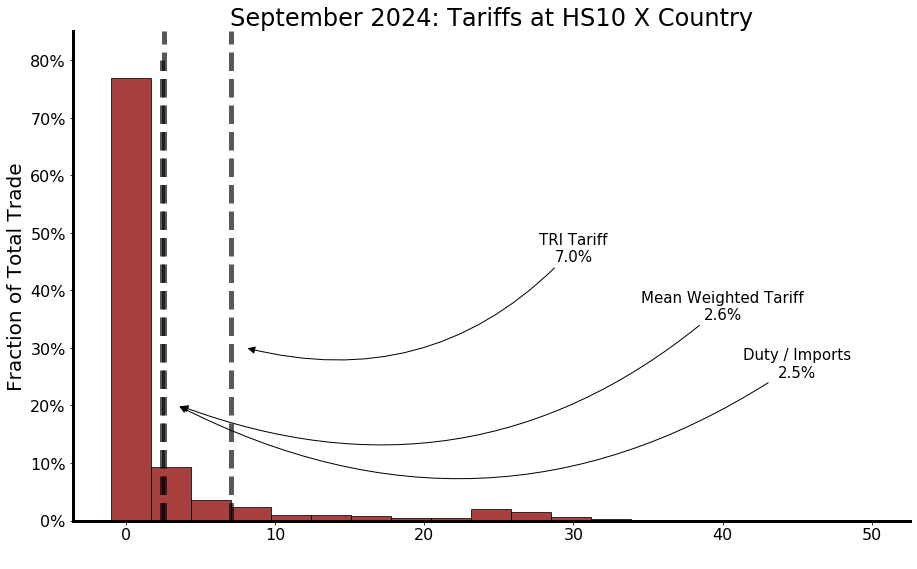

In [11]:
fig, ax = plt.subplots(figsize = (15,9))

# fig = plt.figure(figsize=(15, 9))
# bax_ax = bax.brokenaxes(ylims=((0, 0.20), (0.40, 0.50)), hspace=.05)

bin_edges = np.linspace(-1, 50, 20)  # 50 bins

# Digitize delta_tariff into bins
bin_indices = np.digitize(100*bigdf["tariff"], bin_edges) - 1

# Sum CON_VAL_MO in each bin
bin_sums = np.zeros(len(bin_edges) - 1)

for i in range(len(bin_sums)):

    bin_sums[i] = bigdf.loc[bin_indices == i, "CON_VAL_MO"].sum()

# Convert to fraction of total CON_VAL_MO
fractions = bin_sums / bigdf["CON_VAL_MO"].sum()

ax.bar(bin_edges[:-1], fractions, width=np.diff(bin_edges), 
       align='edge', color='darkred', alpha=0.75, edgecolor='black')



ax.set_ylabel("Fraction of Total Trade", fontsize = 20)

# ax.set_xlabel("Change in HS10 Tariff: May 2025 - May 2024", fontsize = 20)

ax.set_title("September 2024: Tariffs at HS10 X Country", fontsize = 24)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

ax.tick_params(axis='x', labelsize=16)  # Change font size of x-axis tick labels
ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

ax.spines["left"].set_linewidth(3)

ax.spines["bottom"].set_linewidth(3)

# mediantariff = foo["applied_tariff"].median()

ax.vlines(100*sqrtariff, 0, 0.85, 
          linestyles= "dashed", color = "k", linewidth=5, alpha=0.65)

ax.annotate("TRI Tariff\n{:.1f}%".format(100*sqrtariff), 
            xy=(100*sqrtariff+1, 0.3), 
            xytext=(30, 0.45),
            arrowprops={
            "arrowstyle": "-|>", # This is stuff about the arrow
            "connectionstyle": "arc3,rad=-0.3",  # rad controls curve amount,  # Arc with arms
            "color": "black"},
            fontsize=15, color='black',
            ha='center')


ax.vlines(100*meanweighted, 0, 0.85, 
          linestyles= "dashed", color = "k", linewidth=5, alpha=0.65)

ax.annotate("Mean Weighted Tariff\n{:.1f}%".format(100*meanweighted), 
            xy=(100*meanweighted+1, 0.20), 
            xytext=(40, 0.35),
            arrowprops={
            "arrowstyle": "-|>", # This is stuff about the arrow
            "connectionstyle": "arc3,rad=-0.3",  # rad controls curve amount,  # Arc with arms
            "color": "black"},
            fontsize=15, color='black',
            ha='center')


ax.vlines(100*simplemean, 0, 0.80, 
          linestyles= "dashed", color = "k", linewidth=5, alpha=0.65)

ax.annotate("Duty / Imports\n{:.1f}%".format(100*simplemean), 
            xy=(100*simplemean+1, 0.20), 
            xytext=(45, 0.25),
            arrowprops={
            "arrowstyle": "-|>", # This is stuff about the arrow
            "connectionstyle": "arc3,rad=-0.3",  # rad controls curve amount,  # Arc with arms
            "color": "black"},
            fontsize=15, color='black',
            ha='center')

ax.set_ylim(top=0.85)

plt.savefig(figfile+"sept2024-histogram.png", bbox_inches = "tight")

plt.savefig(figfile+"sept2024-histogram.pdf", bbox_inches = "tight")

plt.show()

In [12]:
date_list = ["2024-01", "2024-02", "2024-03", "2024-04", "2024-05", "2024-06", "2024-07", "2024-08", "2024-09", "2024-10", "2024-11", "2024-12",
             "2025-01", "2025-02", "2025-03", "2025-04", "2025-05", "2025-06", "2025-07", "2025-08", "2025-09"]

metrics_df = create_tariff_metrics_by_date_country(country_list, date_list, weight_year="2024")

metrics_df["date"] = pd.to_datetime(metrics_df["date"], format="%Y-%m")


Processing date: 2024-01
Processing date: 2024-02
Processing date: 2024-03
Processing date: 2024-04
Processing date: 2024-05
Processing date: 2024-06
Processing date: 2024-07
Processing date: 2024-08
Processing date: 2024-09
Processing date: 2024-10
Processing date: 2024-11
Processing date: 2024-12
Processing date: 2025-01
Processing date: 2025-02
Processing date: 2025-03
Processing date: 2025-04
Processing date: 2025-05
Processing date: 2025-06
Processing date: 2025-07
Processing date: 2025-08
Processing date: 2025-09


In [13]:
metrics_df["CTY_NAME"].unique()

array(['ALL COUNTRIES', 'CHINA', 'MEXICO', 'CANADA', 'JAPAN', 'GERMANY',
       'KOREA, SOUTH', 'VIETNAM', 'TAIWAN', 'IRELAND', 'INDIA',
       'UNITED KINGDOM', 'ITALY', 'FRANCE', 'SWITZERLAND', 'MALAYSIA',
       'THAILAND', 'BRAZIL', 'SINGAPORE', 'NETHERLANDS', 'INDONESIA',
       'ISRAEL', 'BELGIUM', 'SAUDI ARABIA', 'SPAIN', 'RUSSIA', 'COLOMBIA',
       'AUSTRIA', 'AUSTRALIA', 'SWEDEN', 'CHILE'], dtype=object)

In [14]:
# this loads the statatory tariffs data

stat_tariffs = pd.read_csv('C:\\github\\trade-war-redux-2025\\country-by-time.csv')

stat_tariffs.date = pd.to_datetime(stat_tariffs.date, format="%Y-%m-%d")

stat_tariffs.rename(columns = {"country_name": "CTY_NAME"}, inplace = True)

stat_tariffs["effective tariff"] = 0.01*stat_tariffs["effective tariff"] + 0.01*stat_tariffs["2024 tariff"]

daily_tariff = pd.read_csv("C:\\github\\trade-war-redux-2025\\daily-tariff-latest-data.csv", usecols=["date", "import_weighted_avg_tariff"])

daily_tariff["date"] = pd.to_datetime(daily_tariff["date"])

daily_tariff["CTY_NAME"] = "ALL COUNTRIES"

daily_tariff["import_weighted_avg_tariff"] = 0.01*daily_tariff["import_weighted_avg_tariff"]

daily_tariff.rename(columns = {"import_weighted_avg_tariff":"effective tariff"}, inplace=True)

stat_tariffs = stat_tariffs.append(daily_tariff)


In [15]:
# This is the cell to prepare the data for the app
# Country to flag URL mapping

country_flags = {
    'ALL COUNTRIES': 'https://em-content.zobj.net/thumbs/120/twitter/348/globe-showing-americas_1f30e.png',  # Globe icon
    'CHINA': 'https://flagcdn.com/w40/cn.png',
    'JAPAN': 'https://flagcdn.com/w40/jp.png',
    'MEXICO': 'https://flagcdn.com/w40/mx.png',
    'CANADA': 'https://flagcdn.com/w40/ca.png',
    'VIETNAM': 'https://flagcdn.com/w40/vn.png',
    'KOREA, SOUTH': 'https://flagcdn.com/w40/kr.png',
    'INDIA': 'https://flagcdn.com/w40/in.png',
    'TAIWAN': 'https://flagcdn.com/w40/tw.png',
    'GERMANY': 'https://flagcdn.com/w40/de.png',
    'UNITED KINGDOM': 'https://flagcdn.com/w40/gb.png',
    'FRANCE': 'https://flagcdn.com/w40/fr.png',
    'ITALY': 'https://flagcdn.com/w40/it.png',
    'IRELAND': 'https://flagcdn.com/w40/ie.png',
    'SWITZERLAND': 'https://flagcdn.com/w40/ch.png',
    'THAILAND': 'https://flagcdn.com/w40/th.png',
    'NETHERLANDS': 'https://flagcdn.com/w40/nl.png',
    'BRAZIL': 'https://flagcdn.com/w40/br.png',
    'BELGIUM': 'https://flagcdn.com/w40/be.png',
    'SINGAPORE': 'https://flagcdn.com/w40/sg.png',
    'INDONESIA': 'https://flagcdn.com/w40/id.png',
    'MALAYSIA': 'https://flagcdn.com/w40/my.png',
    'ISRAEL': 'https://flagcdn.com/w40/il.png',
    'SAUDI ARABIA': 'https://flagcdn.com/w40/sa.png',
    'SPAIN': 'https://flagcdn.com/w40/es.png',
    'RUSSIA': 'https://flagcdn.com/w40/ru.png',
    'COLOMBIA': 'https://flagcdn.com/w40/co.png',
    'AUSTRIA': 'https://flagcdn.com/w40/at.png',
    'AUSTRALIA': 'https://flagcdn.com/w40/au.png',
    'SWEDEN': 'https://flagcdn.com/w40/se.png',
    'CHILE': 'https://flagcdn.com/w40/cl.png',
}

# Country to color mapping (using national/flag colors)
country_colors = {
    'ALL COUNTRIES': '#000000',  # Black for ALL COUNTRIES
    'CHINA': '#DE2910',
    'JAPAN': '#BC002D',
    'MEXICO': '#006847',
    'CANADA': '#FF0000',
    'VIETNAM': '#DA251D',
    'KOREA, SOUTH': '#003478',
    'INDIA': '#FF9933',
    'TAIWAN': '#000095',
    'GERMANY': '#FFCE00',
    'UNITED KINGDOM': '#012169',
    'FRANCE': '#0055A4',
    'ITALY': '#009246',
    'IRELAND': '#169B62',
    'SWITZERLAND': '#FF0000',
    'THAILAND': '#2D2A4A',
    'NETHERLANDS': '#FF6600',
    'BRAZIL': '#009B3A',
    'BELGIUM': '#FDDA24',
    'SINGAPORE': '#EE2737',
    'INDONESIA': '#FF0000',
    'MALAYSIA': '#CC0001',
    'ISRAEL': '#0038B8',
    'SAUDI ARABIA': '#165B33',
    'SPAIN': '#AA151B',
    'RUSSIA': '#0039A6',
    'COLOMBIA': '#FCD116',
    'AUSTRIA': '#ED2939',
    'AUSTRALIA': '#012169',
    'SWEDEN': '#006AA7',
    'CHILE': '#D52B1E',
}

# Add flag and color columns
metrics_df['flag'] = metrics_df['CTY_NAME'].map(country_flags)
metrics_df['color'] = metrics_df['CTY_NAME'].map(country_colors)

# Create complete date range from start to 2025-12-30
min_date = metrics_df['date'].min()
max_date = pd.to_datetime('2025-12-30')
full_date_range = pd.date_range(start=min_date, end=max_date, freq='D')

# Resample to daily frequency with forward fill (not interpolation)
daily_data = []

for country in metrics_df['CTY_NAME'].unique():
    country_df = metrics_df[metrics_df['CTY_NAME'] == country].copy()
    country_df = country_df.set_index('date').sort_index()
    
    # Resample to daily and forward fill (each day gets that month's value)
    country_daily = country_df[['sqrtariff', 'meanweighted', 'simplemean', 'duty_total']].resample('D').ffill()
    
    # Reindex to full date range - this will add NaNs for dates beyond available data
    country_daily = country_daily.reindex(full_date_range)
    
    # Add back the country name, flag, and color (constant for each country)
    country_daily['CTY_NAME'] = country
    country_daily['flag'] = country_df['flag'].iloc[0]
    country_daily['color'] = country_df['color'].iloc[0]
    
    country_daily = country_daily.reset_index()
    country_daily.rename(columns={'index': 'date'}, inplace=True)
    daily_data.append(country_daily)

# Combine all countries
app_data = pd.concat(daily_data, ignore_index=True)

app_data = app_data[['date', 'CTY_NAME', 'sqrtariff', 'meanweighted', 'simplemean', 'duty_total', 'flag', 'color']]

app_data = pd.merge(stat_tariffs[["CTY_NAME", "date", "effective tariff"]], app_data, how="right", on=["date", "CTY_NAME"])

# Backfill effective tariff with meanweighted for dates before 2025-02-04
app_data.loc[app_data['date'] < '2025-02-04', 'effective tariff'] = app_data.loc[app_data['date'] < '2025-02-04', 'meanweighted']

# Forward fill effective tariff to propagate values
app_data['effective tariff'] = app_data.groupby('CTY_NAME')['effective tariff'].ffill()

app_data.to_parquet('../TRI-tracker/data/tri-all-country-data.parquet')


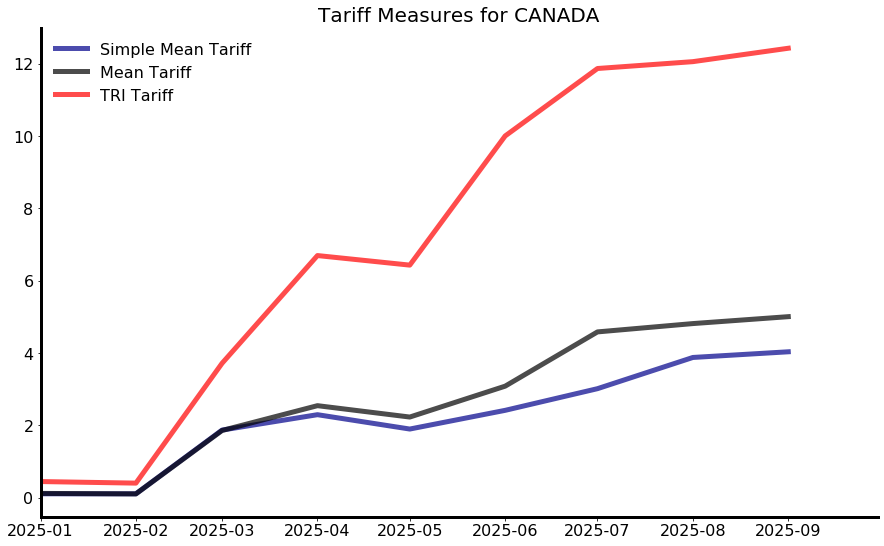

In [16]:
fig, ax = plt.subplots(figsize = (15,9))

foo = metrics_df[metrics_df["CTY_NAME"] == "CANADA"].copy()

ax.plot(foo.date, 100*foo["simplemean"], color = "darkblue", alpha = 0.7, linewidth = 5, label = "Simple Mean Tariff")

ax.plot(foo.date, 100*foo["meanweighted"], color = "black", alpha = 0.7, linewidth = 5, label = "Mean Tariff")

ax.plot(foo.date, 100*foo["sqrtariff"], color = "red", alpha = 0.7, linewidth = 5, label = "TRI Tariff")

ax.set_title("Tariff Measures for " + foo["CTY_NAME"].iloc[0], fontsize = 20)

ax.set_xlim([dt.datetime(2025,1,1), dt.datetime(2025,9,30)])

ax.tick_params(axis='x', labelsize=16)  # Change font size of x-axis tick labels
ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

ax.spines["left"].set_linewidth(3)

ax.spines["bottom"].set_linewidth(3)

ax.legend(
    fontsize=16,           # Font size
    frameon=False,         # No box
    loc='upper left',     # Position
    ncol=1                 # Number of columns
)

ax.set_ylim(top=13)

# plt.savefig(figfile+"canada-tariffs.png", bbox_inches = "tight")

# plt.savefig(figfile+"canada-tariffs.pdf", bbox_inches = "tight")

plt.show()

In [17]:
foo.head()

target_date = "2025-09"

outfoo = foo[foo["date"] == pd.to_datetime(target_date, format="%Y-%m")].copy()

with open(texfile, 'a') as f:
    f.write(f'\\newcommand{{\\canadarmsValuetwofive}}{{{outfoo.sqrtariff.iloc[0]*100:.0f}}}\n')
    f.write(f'\\newcommand{{\\canadameanWeightedValuetwofive}}{{{outfoo.meanweighted.iloc[0]*100:.0f}}}\n')
    f.write(f'\\newcommand{{\\canadasimpleMeanValuetwofive}}{{{outfoo.simplemean.iloc[0]*100:.0f}}}\n')

In [18]:
outfoo.sqrtariff.iloc[0]

0.12427706555805336

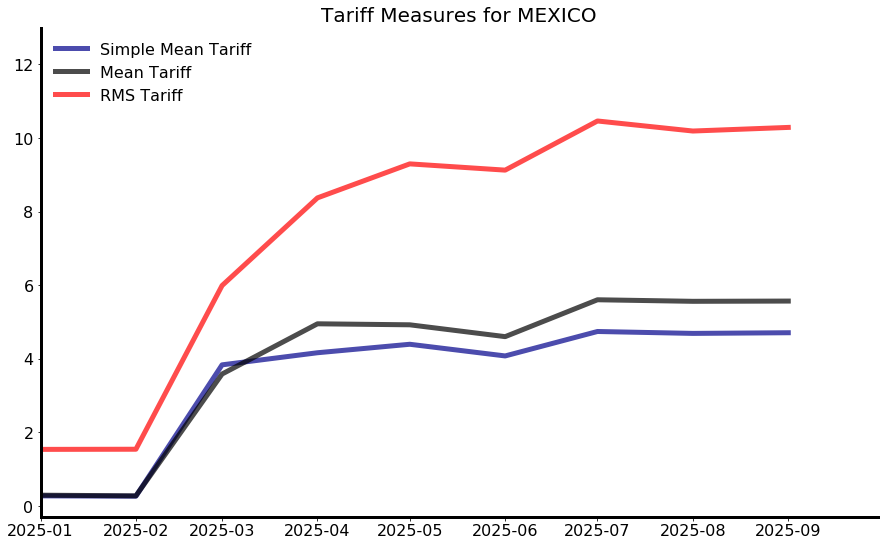

In [19]:
fig, ax = plt.subplots(figsize = (15,9))

foo = metrics_df[metrics_df["CTY_NAME"] == "MEXICO"].copy()

ax.plot(foo.date, 100*foo["simplemean"], color = "darkblue", alpha = 0.7, linewidth = 5, label = "Simple Mean Tariff")

ax.plot(foo.date, 100*foo["meanweighted"], color = "black", alpha = 0.7, linewidth = 5, label = "Mean Tariff")

ax.plot(foo.date, 100*foo["sqrtariff"], color = "red", alpha = 0.7, linewidth = 5, label = "RMS Tariff")

ax.set_title("Tariff Measures for " + foo["CTY_NAME"].iloc[0], fontsize = 20)

ax.set_xlim([dt.datetime(2025,1,1), dt.datetime(2025,9,30)])

ax.tick_params(axis='x', labelsize=16)  # Change font size of x-axis tick labels
ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

ax.spines["left"].set_linewidth(3)

ax.spines["bottom"].set_linewidth(3)

ax.legend(
    fontsize=16,           # Font size
    frameon=False,         # No box
    loc='upper left',     # Position
    ncol=1                 # Number of columns
)

ax.set_ylim(top=13)

# plt.savefig(figfile+"mexico-tariffs.png", bbox_inches = "tight")

# plt.savefig(figfile+"mexico-tariffs.pdf", bbox_inches = "tight")

plt.show()

In [20]:
foo.head()

target_date = "2025-09"

outfoo = foo[foo["date"] == pd.to_datetime(target_date, format="%Y-%m")].copy()

with open(texfile, 'a') as f:
    f.write(f'\\newcommand{{\\mexicormsValuetwofive}}{{{outfoo.sqrtariff.iloc[0]*100:.0f}}}\n')
    f.write(f'\\newcommand{{\\mexicomeanWeightedValuetwofive}}{{{outfoo.meanweighted.iloc[0]*100:.0f}}}\n')
    f.write(f'\\newcommand{{\\mexicosimpleMeanValuetwofive}}{{{outfoo.simplemean.iloc[0]*100:.0f}}}\n')

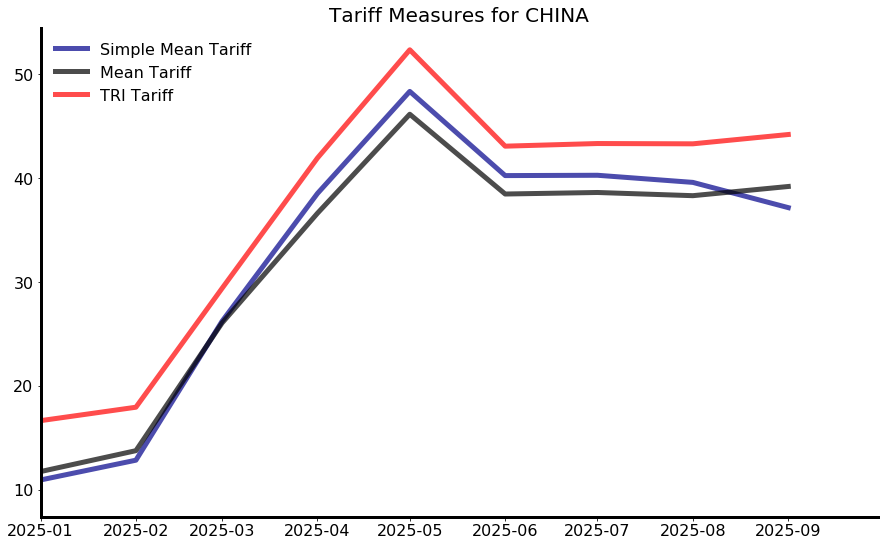

In [21]:
fig, ax = plt.subplots(figsize = (15,9))

foo = metrics_df[metrics_df["CTY_NAME"] == "CHINA"].copy()

ax.plot(foo.date, 100*foo["simplemean"], color = "darkblue", alpha = 0.7, linewidth = 5, label = "Simple Mean Tariff")

ax.plot(foo.date, 100*foo["meanweighted"], color = "black", alpha = 0.7, linewidth = 5, label = "Mean Tariff")

ax.plot(foo.date, 100*foo["sqrtariff"], color = "red", alpha = 0.7, linewidth = 5, label = "TRI Tariff")

ax.set_title("Tariff Measures for " + foo["CTY_NAME"].iloc[0], fontsize = 20)

ax.set_xlim([dt.datetime(2025,1,1), dt.datetime(2025,9,30)])

ax.tick_params(axis='x', labelsize=16)  # Change font size of x-axis tick labels
ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

ax.spines["left"].set_linewidth(3)

ax.spines["bottom"].set_linewidth(3)

ax.legend(
    fontsize=16,           # Font size
    frameon=False,         # No box
    loc='upper left',     # Position
    ncol=1                 # Number of columns
)

# plt.savefig(figfile+"china-tariffs.png", bbox_inches = "tight")

# plt.savefig(figfile+"china-tariffs.pdf", bbox_inches = "tight")

plt.show()

In [22]:
foo.head()

target_date = "2025-09"

outfoo = foo[foo["date"] == pd.to_datetime(target_date, format="%Y-%m")].copy()

with open(texfile, 'a') as f:
    f.write(f'\\newcommand{{\\chinarmsValuetwofive}}{{{outfoo.sqrtariff.iloc[0]*100:.0f}}}\n')
    f.write(f'\\newcommand{{\\chinameanWeightedValuetwofive}}{{{outfoo.meanweighted.iloc[0]*100:.0f}}}\n')
    f.write(f'\\newcommand{{\\chinasimpleMeanValuetwofive}}{{{outfoo.simplemean.iloc[0]*100:.0f}}}\n')

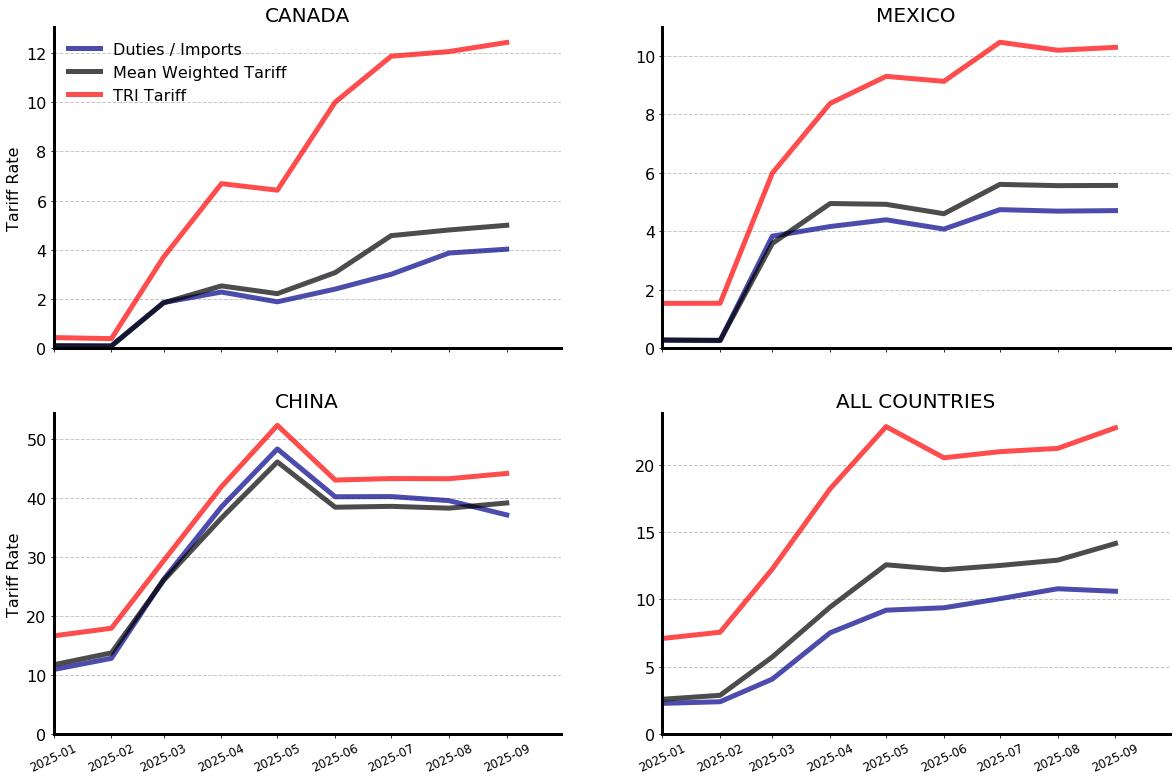

In [23]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, sharex = True, figsize = (20,13)) 

countries = ["CANADA", "MEXICO", "CHINA", "ALL COUNTRIES"]

ax = ax.ravel() # Here is the trick here, ax is a 2 by 2 array. We want to work through it in a loop...so
                # one way to do this is to flatten stuff out, make it a 4 by 1 array. The ravel command 
                # does this...
    
for i, (ax, country) in enumerate(zip(ax, countries)):

    foo = metrics_df[metrics_df["CTY_NAME"] == country].copy()

    ax.plot(foo.date, 100*foo["simplemean"], color = "darkblue", alpha = 0.7, linewidth = 5, label = "Duties / Imports")

    ax.plot(foo.date, 100*foo["meanweighted"], color = "black", alpha = 0.7, linewidth = 5, label = "Mean Weighted Tariff")

    ax.plot(foo.date, 100*foo["sqrtariff"], color = "red", alpha = 0.7, linewidth = 5, label = "TRI Tariff")

    ax.set_title( foo["CTY_NAME"].iloc[0], fontsize = 20)

    ax.set_xlim([dt.datetime(2025,1,1), dt.datetime(2025,9,30)])

    ax.set_ylim(bottom=0)

    ax.tick_params(axis='x', labelsize=12, rotation=25)
    ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

    ax.spines["right"].set_visible(False)

    ax.spines["top"].set_visible(False)

    ax.spines["left"].set_linewidth(3)

    ax.spines["bottom"].set_linewidth(3)

    ax.grid(axis='y', linewidth=1, linestyle='--', alpha=0.7)

    if i == 0:  # Only show legend in first plot
        ax.legend(
            fontsize=16,           # Font size
            frameon=False,         # No box
            loc='upper left',     # Position
            ncol=1                 # Number of columns
        )

        ax.set_ylabel("Tariff Rate", fontsize=16)

    if i == 2:

        ax.set_ylabel("Tariff Rate", fontsize=16)


plt.savefig(figfile+"panel-tariffs.png", bbox_inches = "tight")

plt.savefig(figfile+"panel-tariffs.pdf", bbox_inches = "tight")

plt.show()

In [24]:
foobar = process_countries_for_date(country_list, "2024-09", weight_year="2024", selected_country="SWITZERLAND")

In [25]:
foobar["tariff"] = 100*foobar["tariff"]

In [26]:
foobar.sort_values(by="weights", ascending=False).iloc[0:50]

,I_COMMODITY,CTY_NAME,weights,CON_VAL_MO,CAL_DUT_MO,tariff
77024,3002150091,SWITZERLAND,0.129975,377536909.0,0.0,0.000000
77042,3004909215,SWITZERLAND,0.124019,473671958.0,0.0,0.000000
77823,7115900530,SWITZERLAND,0.081673,984841494.0,0.0,0.000000
79562,9801001028,SWITZERLAND,0.043221,58200011.0,0.0,0.000000
77019,3002120090,SWITZERLAND,0.036308,141920088.0,0.0,0.000000
77043,3004909221,SWITZERLAND,0.028430,108370031.0,0.0,0.000000
79362,9102217010,SWITZERLAND,0.020891,88626616.0,72902.0,0.082257
76746,0901210045,SWITZERLAND,0.019105,104716918.0,0.0,0.000000
77057,3004909291,SWITZERLAND,0.015830,35183466.0,0.0,0.000000
79365,9102219010,SWITZERLAND,0.013712,70002663.0,39673.0,0.056674


In [27]:
metrics_df_2025 = create_tariff_metrics_by_date_country(country_list, ["2025-09"], weight_year="2024")



Processing date: 2025-09


In [32]:
metrics_df_2025[["CTY_NAME", "sqrtariff", "meanweighted", "simplemean"]]

,CTY_NAME,sqrtariff,meanweighted,simplemean
0,ALL COUNTRIES,0.227550,0.141560,0.106030
1,CHINA,0.442024,0.391963,0.371591
2,MEXICO,0.102873,0.055700,0.047097
3,CANADA,0.124277,0.050035,0.040318
4,JAPAN,0.203901,0.167224,0.167908
5,GERMANY,0.176685,0.132484,0.126374
6,"KOREA, SOUTH",0.209267,0.173273,0.157692
7,VIETNAM,0.213016,0.163176,0.124370
8,TAIWAN,0.162960,0.094421,0.050772
9,IRELAND,0.048548,0.015999,0.003970


In [33]:
foo = metrics_df_2025[["CTY_NAME", "sqrtariff", "meanweighted", "simplemean"]].iloc[0:21]

foo = foo.sort_values(by="sqrtariff", ascending=False).reset_index(drop=True)

foo[["sqrtariff", "meanweighted", "simplemean"]] = 100*foo[["sqrtariff", "meanweighted", "simplemean"]]

foo["CTY_NAME"] = foo["CTY_NAME"].str.title()

foo.rename(columns={
    "CTY_NAME": "Country",
    "sqrtariff": "TRI Tariff",
    "meanweighted": "Mean Weighted Tariff",
    "simplemean": "Duties / Imports"
}, inplace=True)

foo.to_latex(tabletex,
            index=False,
            escape=False,
            float_format="%.1f",
            caption='Tariff Metrics by Country: September 2025',
            label='tab:tariff_metrics')

In [29]:
metrics_df_2025.sort_values(by="sqrtariff", ascending=False).iloc[0:21]

,date,CTY_NAME,sqrtariff,meanweighted,simplemean,duty_total
1,2025-09,CHINA,0.442024,0.391963,0.371591,8.495864e+09
17,2025-09,BRAZIL,0.322815,0.199209,0.173085,4.584413e+08
10,2025-09,INDIA,0.265620,0.185066,0.175314,1.336070e+09
0,2025-09,ALL COUNTRIES,0.227550,0.141560,0.106030,2.523790e+10
20,2025-09,INDONESIA,0.222601,0.186046,0.194870,5.275809e+08
7,2025-09,VIETNAM,0.213016,0.163176,0.124370,2.246180e+09
6,2025-09,"KOREA, SOUTH",0.209267,0.173273,0.157692,1.458428e+09
29,2025-09,SWEDEN,0.207920,0.143036,0.156721,1.650575e+08
27,2025-09,AUSTRIA,0.204281,0.141595,0.141170,1.433826e+08
4,2025-09,JAPAN,0.203901,0.167224,0.167908,1.647468e+09


In [30]:
foobar = process_countries_for_date(country_list, "2025-09", weight_year="2024", selected_country="SWITZERLAND")

foobar["tariff"] = 100*foobar["tariff"]

foobar.sort_values(by="weights", ascending=False).iloc[0:50]

,I_COMMODITY,CTY_NAME,weights,CON_VAL_MO,CAL_DUT_MO,tariff
77024,3002150091,SWITZERLAND,0.129975,2737404.0,0.0,0.000000
77042,3004909215,SWITZERLAND,0.124019,585311608.0,0.0,0.000000
77823,7115900530,SWITZERLAND,0.081673,327214064.0,115836.0,0.035401
79562,9801001028,SWITZERLAND,0.043221,453705871.0,0.0,0.000000
77019,3002120090,SWITZERLAND,0.036308,9460992.0,0.0,0.000000
77043,3004909221,SWITZERLAND,0.028430,146199978.0,0.0,0.000000
79362,9102217010,SWITZERLAND,0.020891,23764769.0,3875128.0,16.306188
76746,0901210045,SWITZERLAND,0.019105,0.0,0.0,NaN
77057,3004909291,SWITZERLAND,0.015830,16065865.0,0.0,0.000000
79365,9102219010,SWITZERLAND,0.013712,22603828.0,2966785.0,13.125144
